In [12]:
import os, glob, sys, shutil
import geopandas as gpd
import rioxarray 
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path_is2 = "/Volumes/T7/MOD-IS2-BATHY/debug_refraction/cls/bathymetry.gpkg"
path_reference = "/Volumes/T7/Hawaii_Site_Assessments/CUDEM/cudem_HI_J1199049.tif"

is2 = gpd.read_file(path_is2)
reference = rioxarray.open_rasterio(path_reference, masked=True).squeeze() 
is2 = is2.to_crs(reference.rio.crs)

In [13]:
x_da = xr.DataArray(is2.geometry.x, dims="point")
y_da = xr.DataArray(is2.geometry.y, dims="point")
ref_z = reference.sel(x=x_da, y=y_da, method="nearest")
is2["z_ref"] = ref_z

In [20]:
is2

,segment_id,rgt,cycle,track,spot,x_ph,z_ph,ref_azimuth,ref_elev,solar_elevation,...,surf_left,surf_right,depth,depth_uncorr,z_ph_refr,classification,confidence,profile_id,geometry,z_ref
0,883310,1158,3,2,3,10588.423633,-29.467888,1.857837,1.478387,34.088875,...,-0.175142,1.697575,22.667198,30.324383,-21.810703,5,0.6,20190613_1158_03_3,POINT (-157.69963 21.41214),-22.967743
1,883310,1158,3,2,3,10611.278772,-25.480692,1.857778,1.478387,34.088875,...,-0.175142,1.697575,19.686805,26.337187,-18.830311,5,0.6,20190613_1158_03_3,POINT (-157.69965 21.41194),-22.417292
2,883311,1158,3,2,3,10611.278772,-25.480692,1.857778,1.478387,34.088806,...,-0.175142,1.697575,19.686805,26.337187,-18.830311,5,0.6,20190613_1158_03_3,POINT (-157.69965 21.41194),-22.417292
3,883311,1158,3,2,3,10622.583998,-30.098049,1.857778,1.478387,34.088806,...,-0.175142,1.697575,23.138238,30.954544,-22.281743,5,0.8,20190613_1158_03_3,POINT (-157.69967 21.41184),-22.125238
4,883310,1158,3,2,3,10622.583998,-30.098049,1.857778,1.478387,34.088875,...,-0.175142,1.697575,23.138238,30.954544,-22.281743,5,0.8,20190613_1158_03_3,POINT (-157.69967 21.41184),-22.125238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6422,883631,1158,3,2,3,17063.290060,-3.894352,1.848711,1.478340,34.077599,...,-0.576318,2.161218,3.516809,4.704809,-2.706353,5,0.6,20190613_1158_03_3,POINT (-157.70646 21.35403),-1.241911
6423,883632,1158,3,2,3,17069.365450,-3.947245,1.848681,1.478340,34.077560,...,-0.576318,2.161218,3.556346,4.757701,-2.745889,5,0.6,20190613_1158_03_3,POINT (-157.70647 21.35397),-1.175884
6424,883633,1158,3,2,3,17069.365451,-3.947245,1.848681,1.478340,34.077522,...,-0.576318,2.161218,3.556346,4.757701,-2.745889,5,0.6,20190613_1158_03_3,POINT (-157.70647 21.35397),-1.175884
6425,883633,1158,3,2,3,17070.882989,-3.973702,1.848681,1.478340,34.077522,...,-0.576318,2.161218,3.576123,4.784159,-2.765666,5,0.6,20190613_1158_03_3,POINT (-157.70647 21.35396),-1.175884


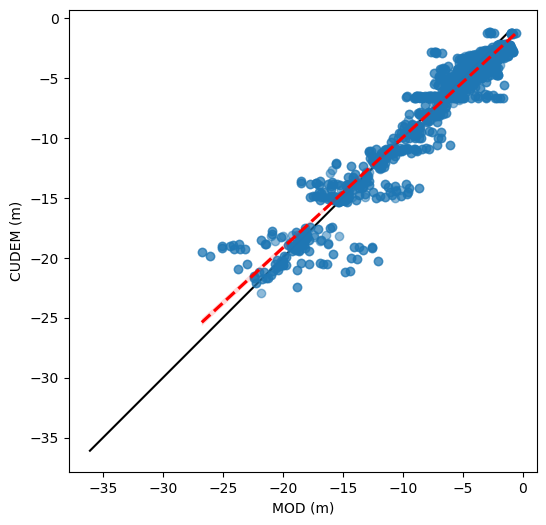

In [22]:
# plot z_ref vs z_ph
rmse = np.sqrt(np.mean((is2.z_ph - is2.z_ref) ** 2))
plt.figure(figsize=(10, 6))
sns.regplot(x=is2.z_ph_refr, y=is2.z_ref, data=is2, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'linestyle': '--'})
plt.xlabel("MOD (m)")
plt.ylabel("CUDEM (m)")
plt.plot([is2.z_ph.min(), is2.z_ph.max()], [is2.z_ph.min(), is2.z_ph.max()], color='black', linestyle='-', zorder=0)
plt.gca().set_aspect('equal', adjustable='box')